**Author:** Steve Landry Ndjock 

**Version:** 1.0

**Python version:**  3.x

In [1]:
%matplotlib inline

# Core libraries
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif, f_regression
from sklearn.experimental import enable_iterative_imputer

from sklearn.dummy import DummyClassifier, DummyRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
)
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)


# Data Preparation

In [2]:
df = pd.read_csv("cmi_internet_copie_2.csv")
df_original = pd.read_csv("dm2_25_26_dataset_tabular/DM2_project/cmi_internet.csv")

In [3]:
from sklearn.datasets import load_breast_cancer

X = df.values
y = np.array(df_original.loc[df.index, 'sii'])

In [4]:
df.head()

,Basic_Demos-Enroll_Season,Basic_Demos-Age,Basic_Demos-Sex,CGAS-Season,CGAS-CGAS_Score,Physical-Season,Physical-BMI,Physical-Height,Physical-Weight,Physical-Waist_Circumference,...,PCIAT-PCIAT_20,SDS-Season,SDS-SDS_Total_Raw,SDS-SDS_Total_T,PreInt_EduHx-Season,PreInt_EduHx-computerinternet_hoursday,FGC_SitReach_Avg,FGC_Grip_Avg,PAQ_Total,Endurance_Total_Sec
0,0,5.0,0.0,3,51.00,0,16.877316,46.0,50.8,26.000,...,4.0,0,56.00,73.80,0,3.0,6.5,20.6250,2.010,448.0
1,2,9.0,0.0,1,58.95,0,14.035590,48.0,46.0,22.000,...,0.0,0,46.00,64.00,2,0.0,11.0,20.6250,2.010,448.0
2,2,10.0,1.0,0,71.00,0,16.648696,56.5,75.6,25.675,...,1.0,0,38.00,54.00,2,2.0,10.0,12.4500,2.009,453.0
3,3,9.0,0.0,0,71.00,2,18.292347,56.0,81.6,26.000,...,1.0,2,31.00,45.00,3,0.0,7.0,20.6250,2.010,577.0
4,1,18.0,1.0,2,65.00,0,17.937682,55.0,77.0,26.000,...,0.9,0,38.45,53.95,1,1.0,9.0,20.9675,1.040,448.0


# Data Partitioning

In [5]:
from sklearn.model_selection import train_test_split, cross_val_score 

from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.metrics import roc_curve, auc, roc_auc_score

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, 
                                                    random_state=100, stratify=y)

In [7]:
X_train.shape

(5922, 83)

# Classification

In [8]:
from sklearn.tree import DecisionTreeClassifier

In [9]:
clf = DecisionTreeClassifier(min_samples_leaf=3, random_state=42)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred, digits=3))

Accuracy 0.698187549251379
F1-score [0.81935123 0.41371681 0.40647482 0.35      ]
              precision    recall  f1-score   support

         0.0      0.802     0.837     0.819      1750
         1.0      0.437     0.393     0.414       476
         2.0      0.419     0.395     0.406       286
         3.0      0.500     0.269     0.350        26

    accuracy                          0.698      2538
   macro avg      0.539     0.474     0.497      2538
weighted avg      0.687     0.698     0.692      2538



# Feature Selection

## Variance Threshold

In [10]:
np.histogram(np.var(X_train, axis=0)[np.var(X_train, axis=0) < 3.14e04])

(array([77,  2,  0,  0,  0,  0,  1,  0,  0,  1], dtype=int64),
 array([7.58721735e-02, 1.12488832e+03, 2.24970077e+03, 3.37451321e+03,
        4.49932566e+03, 5.62413811e+03, 6.74895055e+03, 7.87376300e+03,
        8.99857545e+03, 1.01233879e+04, 1.12482003e+04]))

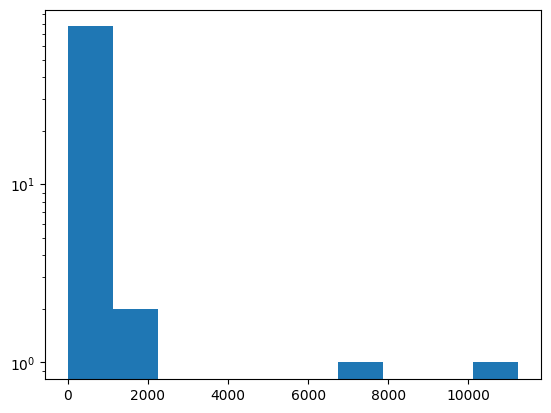

In [11]:
plt.hist(np.var(X_train, axis=0)[np.var(X_train, axis=0) < 3.14e04])
plt.yscale('log')
plt.show()

In [12]:
from sklearn.feature_selection import VarianceThreshold

In [13]:
(.8 * (1 - .8))

0.15999999999999998

In [14]:
sel = VarianceThreshold(threshold=(.8 * (1 - .8)))
X_train_sel = sel.fit_transform(X_train)

X_train_sel.shape

(5922, 77)

In [15]:
X_train.shape

(5922, 83)

In [16]:
X_test_sel = sel.transform(X_test)

clf = DecisionTreeClassifier(min_samples_leaf=3, random_state=42)
clf.fit(X_train_sel, y_train)

y_pred = clf.predict(X_test_sel)

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred, digits=3))

Accuracy 0.6832151300236406
F1-score [0.8096575  0.39524838 0.36823105 0.41176471]
              precision    recall  f1-score   support

         0.0      0.796     0.824     0.810      1750
         1.0      0.407     0.384     0.395       476
         2.0      0.381     0.357     0.368       286
         3.0      0.875     0.269     0.412        26

    accuracy                          0.683      2538
   macro avg      0.615     0.459     0.496      2538
weighted avg      0.677     0.683     0.678      2538



## Univariate Feature Selection

In [17]:
from sklearn.feature_selection import SelectKBest

In [18]:
sel = SelectKBest(k=10)
X_train_sel = sel.fit_transform(X_train, y_train)

X_train_sel.shape

(5922, 10)

In [19]:
sel.scores_

array([4.73447958e-01, 8.54656645e+01, 1.34011282e+01, 1.93965122e+00,
       8.21437758e-01, 1.99625024e+00, 1.96760768e+01, 1.17523665e+02,
       8.67213506e+01, 3.39728488e+01, 7.61150394e+00, 2.16544838e+00,
       2.35118415e+01, 1.51527815e+00, 9.05114380e-01, 1.59822579e+00,
       1.31489336e+00, 7.95691412e-01, 7.26390094e+01, 6.61196127e+00,
       1.24571264e+01, 9.81191786e+00, 8.42081771e+00, 1.14995729e+01,
       4.26880782e+01, 1.88214902e+01, 2.01635461e+00, 1.63829393e+01,
       4.27652544e+00, 1.21166478e+01, 1.15927188e+01, 5.76969871e+00,
       1.15629737e+00, 3.71671797e+00, 1.84490907e+00, 3.42714878e+01,
       5.20095391e+01, 1.47559140e+01, 1.30447595e+01, 8.72694479e+00,
       5.10870561e+00, 2.99389520e+01, 4.66905323e+01, 1.71740232e+01,
       4.53940941e+01, 9.56325289e+00, 2.62726310e+01, 1.70194138e+01,
       3.26977035e+01, 2.96684831e+01, 2.64439088e-01, 2.18504089e+00,
       1.08545382e+00, 3.14954221e+00, 2.90010375e+02, 4.02717085e+02,
      

In [20]:
X_test_sel = sel.transform(X_test)

clf = DecisionTreeClassifier(min_samples_leaf=3, random_state=42)
clf.fit(X_train_sel, y_train)

y_pred = clf.predict(X_test_sel)

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred, digits=3))

Accuracy 0.685973207249803
F1-score [0.81186441 0.39112051 0.4021544  0.42424242]
              precision    recall  f1-score   support

         0.0      0.803     0.821     0.812      1750
         1.0      0.394     0.389     0.391       476
         2.0      0.413     0.392     0.402       286
         3.0      1.000     0.269     0.424        26

    accuracy                          0.686      2538
   macro avg      0.652     0.468     0.507      2538
weighted avg      0.684     0.686     0.683      2538



## Recursive Feature Elimination (RFE)

In [21]:
from sklearn.feature_selection import RFE

In [22]:
sel = RFE(DecisionTreeClassifier(), n_features_to_select=4)
X_train_sel = sel.fit_transform(X_train, y_train)
X_train_sel.shape

(5922, 4)

In [23]:
X_test_sel = sel.transform(X_test)

clf = DecisionTreeClassifier(min_samples_leaf=3, random_state=42)
clf.fit(X_train_sel, y_train)

y_pred = clf.predict(X_test_sel)

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred, digits=3))

Accuracy 0.648936170212766
F1-score [0.79095422 0.28632939 0.29918033 0.42424242]
              precision    recall  f1-score   support

         0.0      0.764     0.819     0.791      1750
         1.0      0.294     0.279     0.286       476
         2.0      0.361     0.255     0.299       286
         3.0      1.000     0.269     0.424        26

    accuracy                          0.649      2538
   macro avg      0.605     0.406     0.450      2538
weighted avg      0.633     0.649     0.637      2538



## Select Form Model
Meta-transformer for selecting features based on importance weights.

In [24]:
from sklearn.feature_selection import SelectFromModel

In [25]:
sel = SelectFromModel(DecisionTreeClassifier())
X_train_sel = sel.fit_transform(X_train, y_train)
X_train_sel.shape

(5922, 26)

In [26]:
X_test_sel = sel.transform(X_test)

clf = DecisionTreeClassifier(min_samples_leaf=3, random_state=42)
clf.fit(X_train_sel, y_train)

y_pred = clf.predict(X_test_sel)

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred, digits=3))

Accuracy 0.6863672182821119
F1-score [0.81565513 0.39522258 0.38655462 0.41176471]
              precision    recall  f1-score   support

         0.0      0.810     0.822     0.816      1750
         1.0      0.409     0.382     0.395       476
         2.0      0.372     0.402     0.387       286
         3.0      0.875     0.269     0.412        26

    accuracy                          0.686      2538
   macro avg      0.616     0.469     0.502      2538
weighted avg      0.686     0.686     0.684      2538



# Feature Projection

## Principal Component Analysis

In [29]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler   

In [31]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [32]:
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

In [33]:
X_train_pca.shape

(5922, 2)

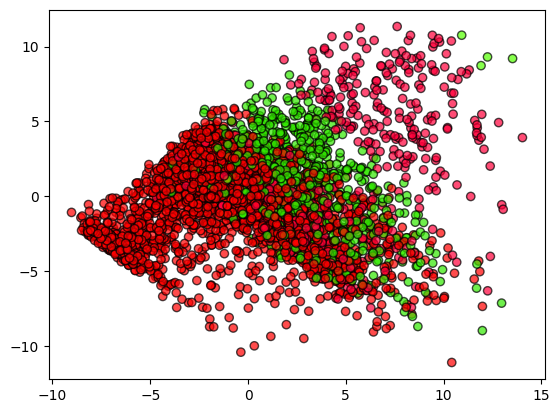

In [34]:
plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train, 
            cmap=plt.cm.prism, edgecolor='k', alpha=0.7)
plt.show()

In [35]:
clf = DecisionTreeClassifier(min_samples_leaf=3, random_state=42)
clf.fit(X_train_pca, y_train)

y_pred = clf.predict(X_test_pca)

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

Accuracy 0.7076438140267928
F1-score [0.81780709 0.39558011 0.49292929 0.37837838]
              precision    recall  f1-score   support

         0.0       0.79      0.85      0.82      1750
         1.0       0.42      0.38      0.40       476
         2.0       0.58      0.43      0.49       286
         3.0       0.64      0.27      0.38        26

    accuracy                           0.71      2538
   macro avg       0.61      0.48      0.52      2538
weighted avg       0.69      0.71      0.70      2538



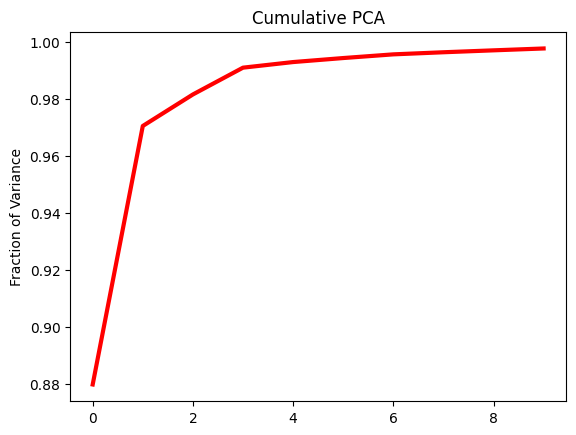

In [36]:
plt.plot(np.cumsum(PCA(n_components=10).fit(X).explained_variance_ratio_), lw=3, color='r', ms=2)
plt.title("Cumulative PCA")
plt.ylabel("Fraction of Variance")
plt.show()

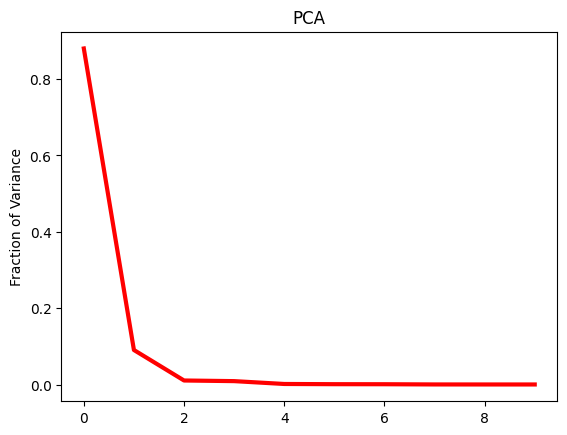

In [37]:
plt.plot(PCA(n_components=10).fit(X).explained_variance_ratio_, lw=3, color='r', ms=2)
plt.title("PCA")
plt.ylabel("Fraction of Variance")
plt.show()

# Random Subspace Projection

In [38]:
from sklearn import random_projection

In [39]:
rsp = random_projection.GaussianRandomProjection(n_components=2, random_state=None)
X_train_rsp = rsp.fit_transform(X_train_scaled)
X_test_rsp = rsp.transform(X_test_scaled)
X_train_rsp.shape

(5922, 2)

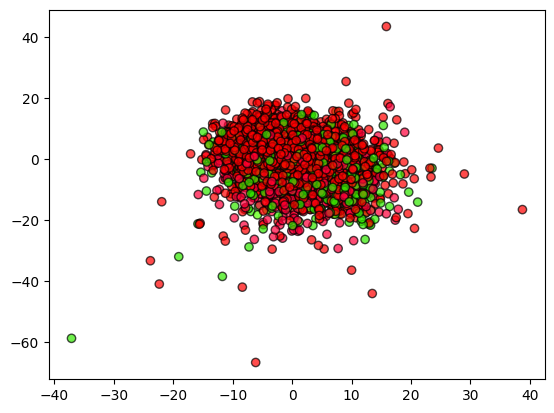

In [40]:
plt.scatter(X_train_rsp[:, 0], X_train_rsp[:, 1], c=y_train, cmap=plt.cm.prism, edgecolor='k', alpha=0.7)
plt.show()

In [41]:
clf = DecisionTreeClassifier(min_samples_leaf=3, random_state=42)
clf.fit(X_train_rsp, y_train)

y_pred = clf.predict(X_test_rsp)

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

Accuracy 0.5890464933018125
F1-score [0.74206897 0.19821826 0.21011673 0.35897436]
              precision    recall  f1-score   support

         0.0       0.72      0.77      0.74      1750
         1.0       0.21      0.19      0.20       476
         2.0       0.24      0.19      0.21       286
         3.0       0.54      0.27      0.36        26

    accuracy                           0.59      2538
   macro avg       0.43      0.35      0.38      2538
weighted avg       0.57      0.59      0.58      2538



## Multi Dimensional Scaling

In [42]:
from sklearn.manifold import MDS

In [43]:
mds = MDS(n_components=2, normalized_stress='auto') #, normalized_stress='auto') # shoudl run as sammon mapping
X_train_mds = mds.fit_transform(X_train_scaled)
X_train_mds.shape

(5922, 2)

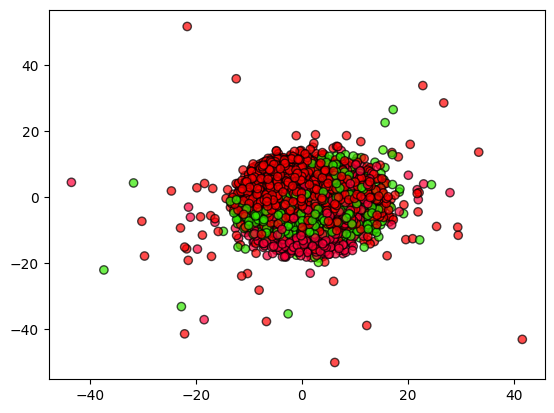

In [44]:
plt.scatter(X_train_mds[:, 0], X_train_mds[:, 1], c=y_train, cmap=plt.cm.prism, edgecolor='k', alpha=0.7)
plt.show()

In [45]:
#X_test_mds = mds.transform(X_test) # no transform

clf = DecisionTreeClassifier(min_samples_leaf=3, random_state=42)
clf.fit(X_train_mds, y_train)

y_pred = clf.predict(X_train_mds)

print('Accuracy %s' % accuracy_score(y_train, y_pred))
print('F1-score %s' % f1_score(y_train, y_pred, average=None))
print(classification_report(y_train, y_pred))

Accuracy 0.8664302600472813
F1-score [0.9221868  0.74218009 0.70989761 0.58064516]
              precision    recall  f1-score   support

         0.0       0.89      0.96      0.92      4083
         1.0       0.78      0.70      0.74      1111
         2.0       0.82      0.62      0.71       666
         3.0       0.87      0.44      0.58        62

    accuracy                           0.87      5922
   macro avg       0.84      0.68      0.74      5922
weighted avg       0.86      0.87      0.86      5922



## IsoMap

In [46]:
from sklearn.manifold import Isomap

In [47]:
iso = Isomap(n_components=2, n_neighbors=5) # n_neighbors=5 is the default, but it is important to specify it here to avoid a warning about future changes in the default value
X_train_iso = iso.fit_transform(X_train_scaled)
X_test_iso = iso.transform(X_test_scaled)
X_train_iso.shape

(5922, 2)

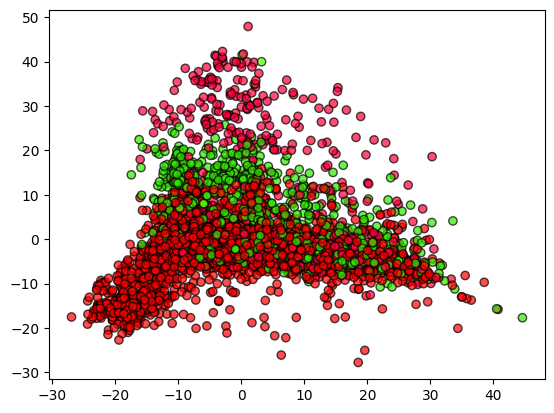

In [48]:
plt.scatter(X_train_iso[:, 0], X_train_iso[:, 1], c=y_train, cmap=plt.cm.prism, edgecolor='k', alpha=0.7)
plt.show()

In [49]:
clf = DecisionTreeClassifier(min_samples_leaf=3, random_state=42)
clf.fit(X_train_iso, y_train)

y_pred = clf.predict(X_test_iso)

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

Accuracy 0.6753349093774625
F1-score [0.79901289 0.32474804 0.42020202 0.3902439 ]
              precision    recall  f1-score   support

         0.0       0.77      0.83      0.80      1750
         1.0       0.35      0.30      0.32       476
         2.0       0.50      0.36      0.42       286
         3.0       0.53      0.31      0.39        26

    accuracy                           0.68      2538
   macro avg       0.54      0.45      0.48      2538
weighted avg       0.66      0.68      0.66      2538



## t-SNE

In [50]:
from sklearn.manifold import TSNE

In [51]:
tsne = TSNE(n_components=2)
X_train_tsne = tsne.fit_transform(X_train_scaled)
X_train_tsne.shape

(5922, 2)

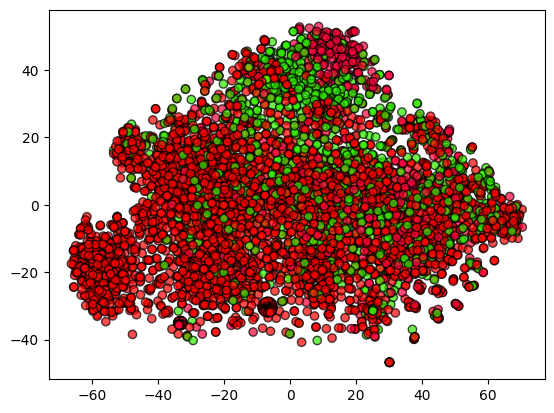

In [52]:
plt.scatter(X_train_tsne[:, 0], X_train_tsne[:, 1], c=y_train, cmap=plt.cm.prism, edgecolor='k', alpha=0.7)
plt.show()

In [53]:
#X_test_mds = mds.transform(X_test) # no transform

clf = DecisionTreeClassifier(min_samples_leaf=3, random_state=42)
clf.fit(X_train_tsne, y_train)

y_pred = clf.predict(X_train_tsne)

print('Accuracy %s' % accuracy_score(y_train, y_pred))
print('F1-score %s' % f1_score(y_train, y_pred, average=None))
print(classification_report(y_train, y_pred))

Accuracy 0.873015873015873
F1-score [0.92610137 0.75971897 0.71636675 0.63265306]
              precision    recall  f1-score   support

         0.0       0.90      0.96      0.93      4083
         1.0       0.79      0.73      0.76      1111
         2.0       0.83      0.63      0.72       666
         3.0       0.86      0.50      0.63        62

    accuracy                           0.87      5922
   macro avg       0.85      0.70      0.76      5922
weighted avg       0.87      0.87      0.87      5922

